C:\Users\reymo\AppData\Local\Temp\ipykernel_9888\1271195690.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(["{:,.0%}".format(x) for x in vals])


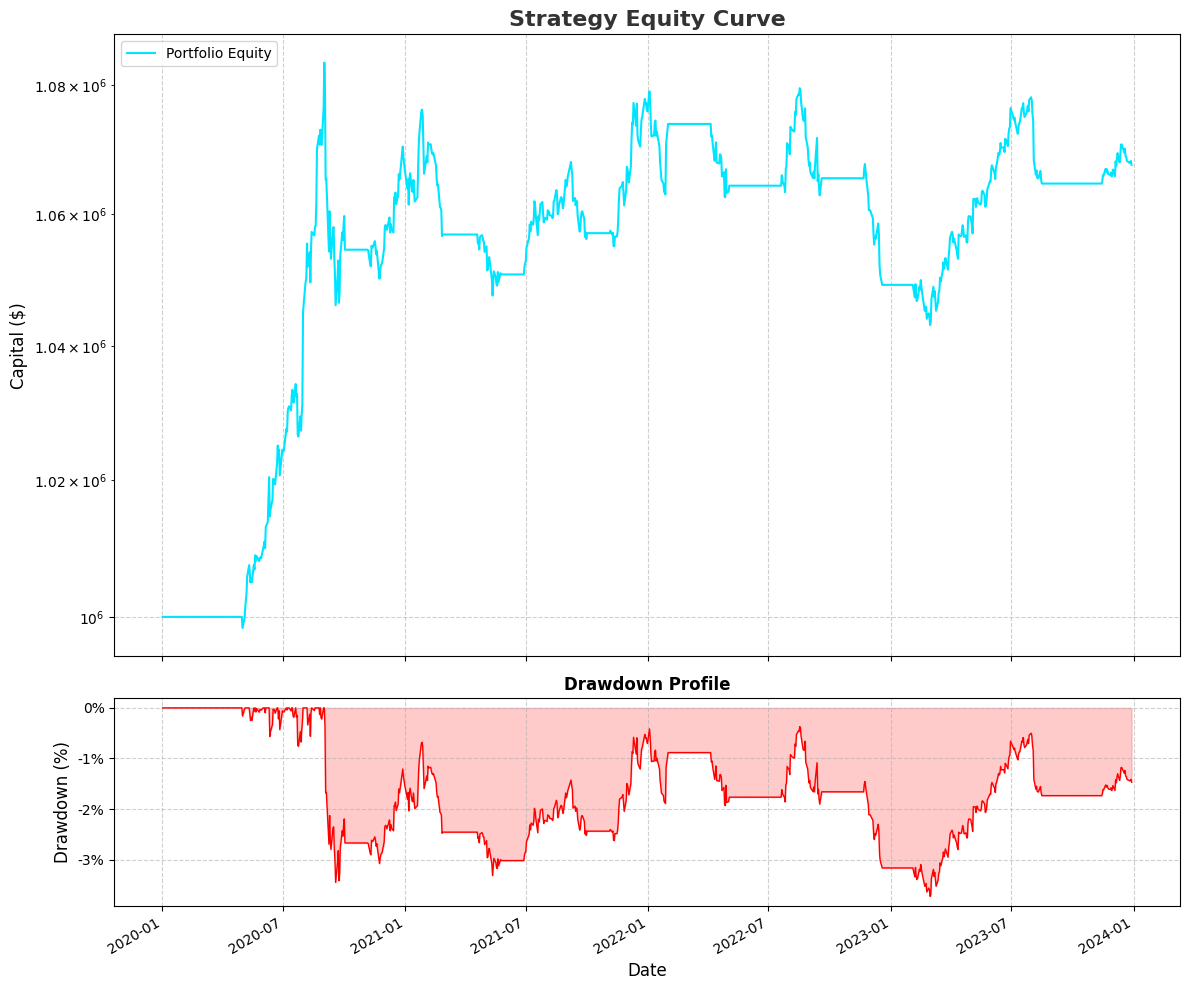

--- PERFORMANCE METRICS ---
Final Equity:   $1,067,580.81
Max Drawdown:   -3.73%
Total Return:   6.76%


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv(
    "../backtest_results.csv", parse_dates=["timestamp"], index_col="timestamp"
)

# 2. Set up the canvas
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 10), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)

# CHART 1: Equity Curve
ax1.plot(
    df.index, df["total"], color="#00E5FF", linewidth=1.5, label="Portfolio Equity"
)

# Stylistics
ax1.set_title("Strategy Equity Curve", fontsize=16, fontweight="bold", color="#333333")
ax1.set_ylabel("Capital ($)", fontsize=12)
ax1.grid(True, which="major", linestyle="--", alpha=0.6)
ax1.legend(loc="upper left")
ax1.set_yscale("log")

# CHART 2: Drawdown
ax2.fill_between(df.index, df["drawdown"], 0, color="#FF5252", alpha=0.3)
ax2.plot(df.index, df["drawdown"], color="#FF0000", linewidth=1, label="Drawdown")

# Stylistics
ax2.set_title("Drawdown Profile", fontsize=12, fontweight="bold")
ax2.set_ylabel("Drawdown (%)", fontsize=12)
ax2.set_xlabel("Date", fontsize=12)
ax2.grid(True, which="major", linestyle="--", alpha=0.6)

# Format Y-axis as percentage (e.g., -0.10 -> -10%)
vals = ax2.get_yticks()
ax2.set_yticklabels(["{:,.0%}".format(x) for x in vals])

# Date Formatting
fig.autofmt_xdate()

# Display
plt.tight_layout()
plt.show()

# Statistics block
print("--- PERFORMANCE METRICS ---")
print(f"Final Equity:   ${df['total'].iloc[-1]:,.2f}")
print(f"Max Drawdown:   {df['drawdown'].min():.2%}")
print(
    f"Total Return:   {(df['total'].iloc[-1] - df['total'].iloc[0]) / df['total'].iloc[0]:.2%}"
)